In [16]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from natsort import natsorted
from scipy.stats import ttest_ind

In [17]:
deaf = pd.read_csv('../Derivatives/deaf_parcel_stats.tsv', sep='\t') #../derivatives/
blind = pd.read_csv('../Derivatives/blind_parcel_stats.tsv', sep='\t') #../derivatives/
deaf['label'] = [str(x)+'_'+str(y) for x,y in zip(deaf['hemi'], deaf['label'])]
blind['label'] = [str(x)+'_'+str(y) for x,y in zip(blind['hemi'], blind['label'])]

/tmp/ipykernel_1624607/1631095265.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  deaf = pd.read_csv('../Derivatives/deaf_parcel_stats.tsv', sep='\t') #../derivatives/


In [18]:
deaf_curvature = pd.read_csv('../Derivatives/deaf_curvature_index_vertexwise.tsv', sep='\t')
blind_curvature = pd.read_csv('../Derivatives/blind_curvature_index_vertexwise.tsv', sep='\t')

In [19]:
mask = deaf['parcellation'] == 'JulichBrain'

# Make sure the rows align: same order in deaf and deaf_curvature for JulichBrain
# Sort both DataFrames by subject, hemi, label (or whatever uniquely identifies rows)
deaf_subset = deaf.loc[mask].sort_values(['subject', 'hemi', 'label']).copy()
curv_subset = deaf_curvature[deaf_curvature['parcellation'] == 'JulichBrain'] \
                .sort_values(['subject', 'hemi', 'label']).copy()

# Replace the column safely
#deaf.loc[mask, 'curvature_index'] = curv_subset['curvature_index'].values

In [20]:
mask = blind['parcellation'] == 'atlas-wang_space-fsaverage'

# Make sure the rows align: same order in deaf and deaf_curvature for JulichBrain
# Sort both DataFrames by subject, hemi, label (or whatever uniquely identifies rows)
blind_subset = blind.loc[mask].sort_values(['subject', 'hemi', 'label']).copy()
curv_subset = blind_curvature[blind_curvature['parcellation'] == 'atlas-wang_space-fsaverage'] \
                .sort_values(['subject', 'hemi', 'label']).copy()

# Replace the column safely
#blind.loc[mask, 'curvature_index'] = curv_subset['curvature_index'].values

In [21]:
deaf = deaf[deaf.parcellation=='JulichBrain'].loc[:, ['subject', 'label', 'surf_area_mm2', 'graymatter_volume', 'avg_thickness_mm',
       'std_thickness_mm', 'mean_curvature', 'gausian_curvature', 'fold_index',
       'curvature_index']].groupby(['subject', 'label']).mean().reset_index()
blind = blind[blind.parcellation=='atlas-wang_space-fsaverage'].loc[:, ['subject', 'label', 'surf_area_mm2', 'graymatter_volume', 'avg_thickness_mm',
       'std_thickness_mm', 'mean_curvature', 'gausian_curvature', 'fold_index',
       'curvature_index']].groupby(['subject', 'label']).mean().reset_index()
blind = blind[blind.label!='lh_0']
blind = blind[blind.label!='rh_0']

#deaf['curvature_index'] = deaf['curvature_index']/deaf['surf_area_mm2']
#blind['curvature_index'] = blind['curvature_index']/blind['surf_area_mm2']

In [22]:
blind['group'] = [t[4:6] for t in blind.subject]

In [23]:
demo = pd.read_csv('../Dataset/deaf/participant_cleaned.csv')
demo['subject'] = ['sub-'+x for x in demo.Code]
deaf = pd.merge(deaf, demo, on='subject', how='left')

In [24]:
wanglabel =  [x.split(' - ')[1] for x in pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values] + [x.split(' - ')[1] for x in pd.read_csv('/mnt/DataDrive3/NishioM/Blind/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values]

In [25]:
blind['hemi'] = [l.split('_')[0] for l in blind['label']]
blind['parcel'] = [l.split('_')[1] for l in blind['label']]
blind['region'] = [wanglabel[int(p)-1] for p in blind['parcel']]

In [26]:
streams = {
    'Primary': ['V1v','V1d','V2v','V2d','V3v','V3d','hV4'],
    'Ventral': ['VO1','VO2','PHC2','PHC1'],
    'Lateral': ['LO1','LO2','hMT','MST'],
    'Dorsal': ['V3a','V3b','IPS0','IPS1','IPS2','IPS3','IPS4','IPS5','SPL1']
}
stream_order = ['Primary', 'Dorsal', 'Lateral', 'Ventral']
roi_to_stream = {roi: stream for stream, rois in streams.items() for roi in rois}
blind['stream'] = blind['region'].map(roi_to_stream)

surf_area_mm2 -3.820734045252166 0.0005579758464559597
graymatter_volume -1.3364491434749632 0.19054479385070133
avg_thickness_mm 6.076548222773029 7.70301655341953e-07
std_thickness_mm 0.510060514252266 0.6134038457847334
mean_curvature 2.094010816791747 0.0440201379864488
gausian_curvature 1.5788195895187853 0.12391645982127425
fold_index -1.6087389193312678 0.11720000677106258
curvature_index -1.8948112727726831 0.06690738618968982


/tmp/ipykernel_1624607/2112603855.py:109: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


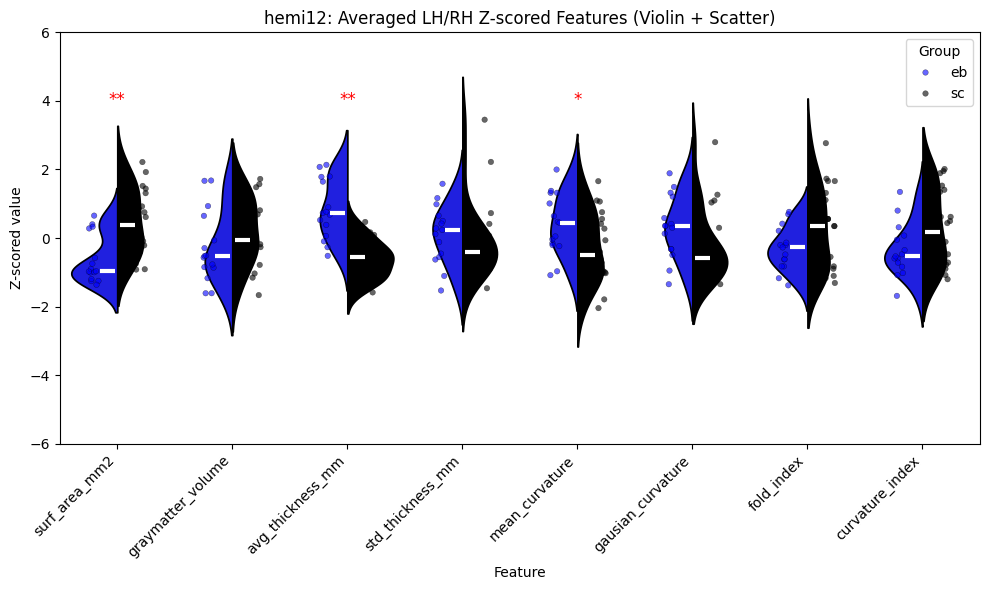

surf_area_mm2 -2.4318146937469827 0.020615058230715966
graymatter_volume -0.28719822657191796 0.7757562886055794
avg_thickness_mm 3.608180739609964 0.0010075579317143906
std_thickness_mm 2.6993414457086926 0.01087018740461678
mean_curvature 1.0517659694841561 0.30054803302886135
gausian_curvature 0.021378999081972962 0.9830720745065977
fold_index -1.9948687093059774 0.054369989791755634
curvature_index -2.1307856157513916 0.040647887187069666


/tmp/ipykernel_1624607/2112603855.py:109: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


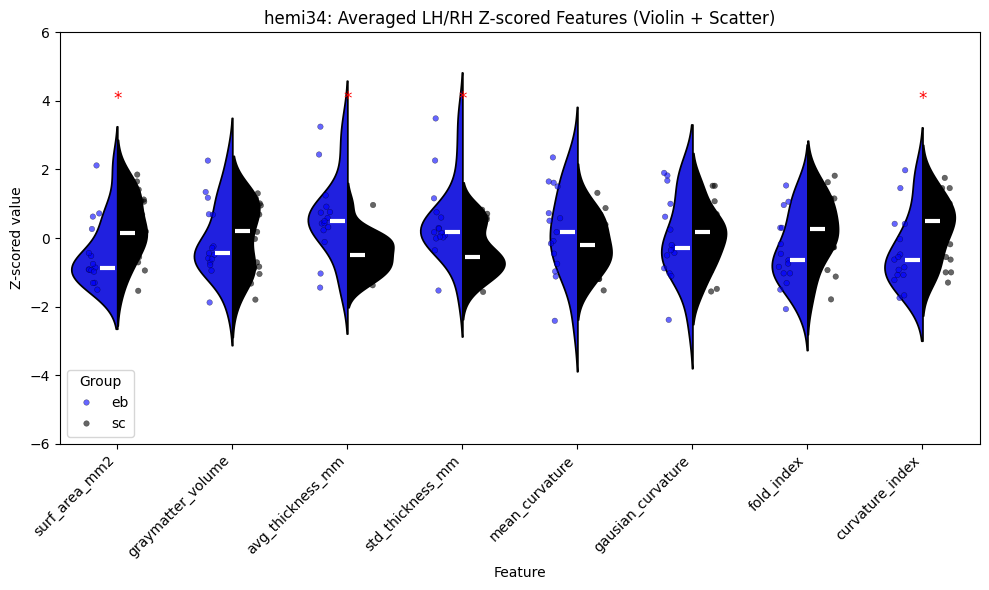

surf_area_mm2 -1.3560597727162502 0.18428720143168942
graymatter_volume 0.25050958145517715 0.8037464357085322
avg_thickness_mm 3.0017136329320575 0.005084665201351167
std_thickness_mm 2.4123788771246044 0.02156834668650238
mean_curvature 0.931488277043547 0.3583661161337558
gausian_curvature 0.5468650541225258 0.5881506555144376
fold_index -0.6900495928096677 0.49498768772419677
curvature_index -0.4576847385116016 0.6501782842667578


/tmp/ipykernel_1624607/2112603855.py:109: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


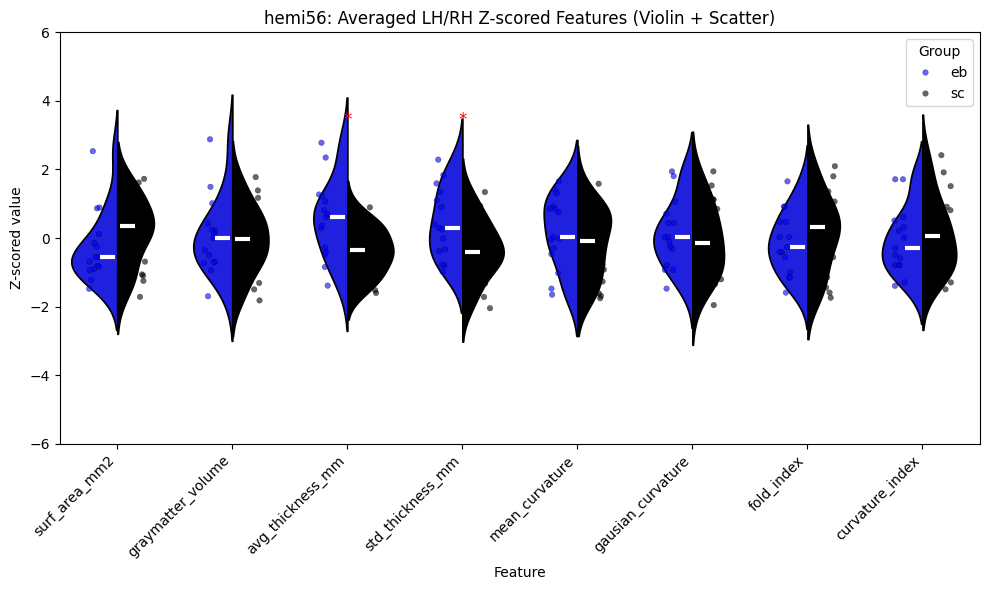

In [27]:
features = [
    'surf_area_mm2', 'graymatter_volume', 'avg_thickness_mm',
    'std_thickness_mm', 'mean_curvature', 'gausian_curvature',
    'fold_index', 'curvature_index'
]

groups = ['eb', 'sc']

# Filter EB and SC only
df = blind[blind.group.isin(groups)].copy()

# ---- Define new hemi pairs ----
hemi_pairs = {
    'hemi12': ['1','2'],
    'hemi34': ['3','4'],
    'hemi56': ['5','6']
}

avg_list = []

# ---- Average across hemisphere pairs ----
for new_hemi, pair in hemi_pairs.items():
    hemi1, hemi2 = pair
    lh1 = df[df.label == f'lh_{hemi1}']
    rh1 = df[df.label == f'rh_{hemi1}']
    lh2 = df[df.label == f'lh_{hemi2}']
    rh2 = df[df.label == f'rh_{hemi2}']

    merged = lh1.merge(rh1, on=['subject','group'], suffixes=('_lh1','_rh1')) \
                .merge(lh2, on=['subject','group']) \
                .merge(rh2, on=['subject','group'], suffixes=('_lh2','_rh2'))

    avg_features = {}
    for f in features:
        avg_features[f] = (merged[f+'_lh1'] + merged[f+'_rh1'] + merged[f+'_lh2'] + merged[f+'_rh2']) / 4

    avg_features['group'] = merged['group']
    avg_features['subject'] = merged['subject']
    avg_features['hemi'] = new_hemi

    avg_list.append(pd.DataFrame(avg_features))

df_avg = pd.concat(avg_list, ignore_index=True)

# ---- Z-score features per new hemi ----
df_avg[features] = df_avg.groupby('hemi')[features].transform(lambda x: zscore(x, nan_policy='omit'))

# ---- Plotting violin + scatter ----
palette = {'eb': 'blue', 'sc': 'black'}

for new_hemi in df_avg['hemi'].unique():
    sub = df_avg[df_avg.hemi == new_hemi].copy()

    # Melt for seaborn
    melt_df = sub[['group','subject'] + features].melt(
        id_vars=['group','subject'],
        value_vars=features,
        var_name='feature',
        value_name='value'
    )
    if new_hemi == 'hemi12':
      blind_V1 = melt_df.copy()  

    plt.figure(figsize=(10, 6))

    # Violin plot
    ax = sns.violinplot(
        data=melt_df,
        x='feature',
        y='value',
        hue='group',
        palette=palette,
        split=True,
        inner=None,
        #cut=0
    )

    region_order = melt_df['feature'].unique()

    # Compute medians
    medians = (
        melt_df.groupby(['feature', 'group'])['value']
        .median()
        .reset_index()
    )

    # Draw median lines
    offset = 0.15  # adjust based on violin width

    for i, region in enumerate(region_order):
        for group, sign in zip(['eb', 'sc'], [-1, 1]):
            median = medians.loc[
                (medians['feature'] == region) &
                (medians['group'] == group),
                'value'
            ].values[0]

            plt.hlines(
                y=median,
                xmin=i + sign*0.02,
                xmax=i + sign*offset,
                color='white',
                linewidth=3,
                zorder=10
            )


    # Scatter overlay
    sns.stripplot(
        data=melt_df,
        x='feature',
        y='value',
        hue='group',
        palette=palette,
        dodge=True,
        jitter=True,
        size=4,
        alpha=0.6,
        edgecolor='gray',
        linewidth=0.3,
        ax=ax
    )

    # Remove duplicate legends
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title='Group')

    # ---- t-test significance stars ----
    y_max = melt_df['value'].max()
    for i, feature in enumerate(features):
        eb_vals = melt_df[(melt_df.feature==feature) & (melt_df.group=='eb')]['value']
        sc_vals = melt_df[(melt_df.feature==feature) & (melt_df.group=='sc')]['value']
        t, p = ttest_ind(eb_vals, sc_vals, nan_policy='omit')
        if p < 0.001:
            sig = '**'
        elif p < 0.05:
            sig = '*'
        else:
            sig = ''
        if sig:
            ax.text(i, y_max + 0.3, sig, ha='center', va='bottom', fontsize=12, color='red')
        print(feature, t, p)

    plt.title(f"{new_hemi}: Averaged LH/RH Z-scored Features (Violin + Scatter)")
    plt.xlabel("Feature")
    plt.ylabel("Z-scored value")
    plt.ylim([-6, 6])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

surf_area_mm2 -2.2025768880762397 0.031757530348853
graymatter_volume 0.7339262469113011 0.46605550278949126
avg_thickness_mm 3.985239459381993 0.0001969272336991117
std_thickness_mm -0.5494307342514684 0.5848943631153851
mean_curvature -0.3006734882415653 0.7647769689751802
gausian_curvature -1.2091698083096993 0.23167802852374686
fold_index 1.1449219743905075 0.25711127616777146
curvature_index -2.09527580345279 0.040680843889970814


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


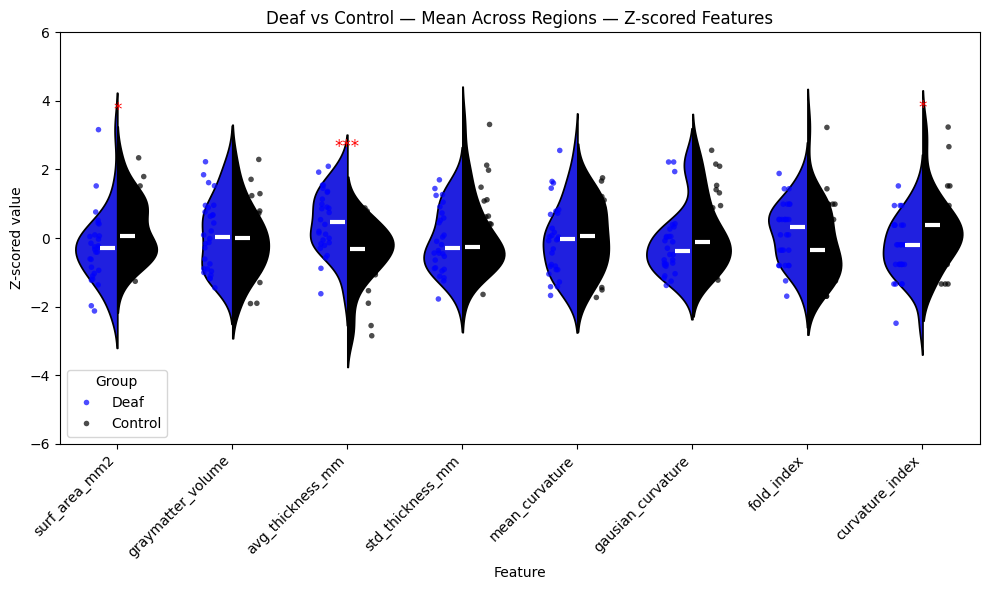

In [28]:
# ----------------------------
# Define features
# ----------------------------
features = [
    'surf_area_mm2', 'graymatter_volume', 'avg_thickness_mm',
    'std_thickness_mm', 'mean_curvature', 'gausian_curvature',
    'fold_index', 'curvature_index'
]

# ----------------------------
# Filter Deaf and Control only
# ----------------------------
df = deaf[deaf.group.isin(['Deaf', 'Control'])].copy()
df['area'] = df['label'].str.replace('lh_', '').str.replace('rh_', '')

# ----------------------------
# Average LH and RH
# ----------------------------
avg_rows = []

areas = ['Area TE 1.0 (HESCHL)', 'Area TE 1.1 (HESCHL)', 'Area TE 1.2 (HESCHL)'] #'Area STS1 (STS)', 'Area STS2 (STS)''Area TE 3 (STG)']#, 'Area TE 2.2 (STG)']#'Area TE 1.0 (HESCHL)', 'Area TE 1.1 (HESCHL)', 'Area TE 1.2 (HESCHL)'] #df['area'].unique()

for area in areas:
    lh = df[(df.area == area) & df.label.str.startswith('lh_')]
    rh = df[(df.area == area) & df.label.str.startswith('rh_')]

    merged = lh.merge(
        rh,
        on=['subject', 'group'],
        suffixes=('_lh', '_rh')
    )

    averaged = {'subject': merged['subject'], 'group': merged['group']}
    for f in features:
        averaged[f] = (merged[f + '_lh'] + merged[f + '_rh']) / 2

    avg_rows.append(pd.DataFrame(averaged))

df_avg = pd.concat(avg_rows, ignore_index=True)

# ----------------------------
# Collapse across regions: mean per subject per feature
# ----------------------------
df_mean = df_avg.groupby(['subject','group'])[features].mean().reset_index()

# ----------------------------
# Z-score features across subjects
# ----------------------------
df_mean[features] = df_mean[features].apply(lambda x: zscore(x, nan_policy='omit'))

# ----------------------------
# Melt for plotting
# ----------------------------
melt_df = df_mean.melt(
    id_vars=['subject','group'],
    value_vars=features,
    var_name='feature',
    value_name='value'
)
deaf_A1 = melt_df.copy()

# ----------------------------
# Compute t-tests for Deaf vs Control per feature
# ----------------------------
sig_labels = []
for f in features:
    d = df_mean[df_mean.group=='Deaf'][f]
    c = df_mean[df_mean.group=='Control'][f]
    t, p = ttest_ind(d, c, nan_policy='omit')
    print(f, t, p)

    if p < 0.001:
        sig_labels.append('***')
    elif p < 0.01:
        sig_labels.append('**')
    elif p < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# ----------------------------
# Plot violin + scatter
# ----------------------------
plt.figure(figsize=(10,6))
sns.violinplot(
    data=melt_df,
    x='feature',
    y='value',
    hue='group',
    palette={'Deaf': 'blue', 'Control': 'black'},
    split=True,
    inner=None
)
region_order = melt_df['feature'].unique()

# Compute medians
medians = (
    melt_df.groupby(['feature', 'group'])['value']
    .median()
    .reset_index()
)

# Draw median lines
offset = 0.15  # adjust based on violin width

for i, region in enumerate(region_order):
    for group, sign in zip(['Deaf', 'Control'], [-1, 1]):
        median = medians.loc[
            (medians['feature'] == region) &
            (medians['group'] == group),
            'value'
        ].values[0]

        plt.hlines(
            y=median,
            xmin=i + sign*0.02,
            xmax=i + sign*offset,
            color='white',
            linewidth=3,
            zorder=10
        )


sns.stripplot(
    data=melt_df,
    x='feature',
    y='value',
    hue='group',
    palette={'Deaf': 'blue', 'Control': 'black'},
    dodge=True,
    jitter=True,
    size=4,
    alpha=0.7,
    marker='o'
)

# Remove duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Group')

# Add t-test significance
for i, label in enumerate(sig_labels):
    if label != 'ns':
        y_max = melt_df[melt_df.feature == features[i]]['value'].max()
        plt.text(i, y_max + 0.3, label, ha='center', va='bottom', fontsize=12, color='red')

plt.title("Deaf vs Control — Mean Across Regions — Z-scored Features")
plt.xlabel("Feature")
plt.ylabel("Z-scored value")
plt.ylim([-6, 6])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('violinplot_TE1.eps')
plt.show()
